4. Implement K-means clustering using MapReduce.

Iteration 1: [[array([1, 2]), array([2, 1]), array([3, 3]), array([2, 3]), array([3, 2])], [array([8, 8]), array([9, 9]), array([10, 10]), array([10, 11]), array([11, 10]), array([12, 12]), array([7, 8]), array([12,  9]), array([ 9, 10])], [array([5, 5]), array([6, 6]), array([7, 5]), array([6, 7])]]


Iteration 2: [[array([1, 2]), array([2, 1]), array([3, 3]), array([2, 3]), array([3, 2])], [array([8, 8]), array([9, 9]), array([10, 10]), array([10, 11]), array([11, 10]), array([12, 12]), array([12,  9]), array([ 9, 10])], [array([5, 5]), array([6, 6]), array([7, 5]), array([7, 8]), array([6, 7])]]


Iteration 3: [[array([1, 2]), array([2, 1]), array([3, 3]), array([2, 3]), array([3, 2])], [array([9, 9]), array([10, 10]), array([10, 11]), array([11, 10]), array([12, 12]), array([12,  9]), array([ 9, 10])], [array([8, 8]), array([5, 5]), array([6, 6]), array([7, 5]), array([7, 8]), array([6, 7])]]


Iteration 4: [[array([1, 2]), array([2, 1]), array([3, 3]), array([2, 3]), array([3, 2])

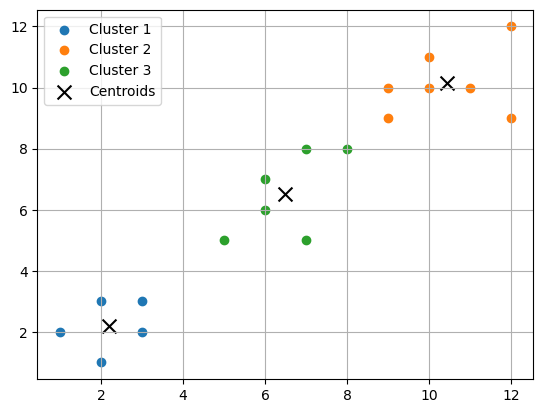

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Larger dataset (2D points)
data = np.array([
    [1, 2], [2, 1], [3, 3], [8, 8], [9, 9], [10, 10], 
    [2, 3], [3, 2], [10, 11], [11, 10], [12, 12], [5, 5], 
    [6, 6], [7, 5], [7, 8], [6, 7], [12, 9], [9, 10]
])

# Initialize random centroids
centroids = np.array([
    [2, 2], [9, 9], [6, 5]
])

def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def assign_clusters(data, centroids):
    clusters = [[] for _ in centroids]
    for point in data:
        distances = [euclidean_distance(point, c) for c in centroids]
        cluster_idx = np.argmin(distances)
        clusters[cluster_idx].append(point)
    return clusters

def update_centroids(clusters):
    return np.array([np.mean(cluster, axis=0) for cluster in clusters])

def kmeans(data, centroids, iterations=5):
    for i in range(iterations):
        clusters = assign_clusters(data, centroids)
        print(f"Iteration {i + 1}: {clusters}")
        print("\n")
        centroids = update_centroids(clusters)
    return centroids, clusters

final_centroids, final_clusters = kmeans(data, centroids)

for i, cluster in enumerate(final_clusters):
    cluster = np.array(cluster)
    plt.scatter(cluster[:, 0], cluster[:, 1], label=f'Cluster {i + 1}')

print("Final Centroids: \n",final_centroids,"\n")
plt.scatter(final_centroids[:, 0], final_centroids[:, 1], color='black', marker='x', s=100, label='Centroids')
plt.legend()
plt.grid()
plt.show()